# Signature Plot, Epps Effect and Link between Spread and Volatility per trade

In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install --upgrade pip
!pip install tables
!pip install pytables


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/8a/6a/19e9fe04fca059ccf770861c7d5721ab4c2aebc539889e97c7977528a53b/pip-24.0-py3-none-any.whl.metadata
  Using cached pip-24.0-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-24.0-py3-none-any.whl (2.1 MB)


ERROR: To modify pip, please run the following command:
C:\Users\hamza\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement pytables (from versions: none)
ERROR: No matching distribution found for pytables

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import datetime as dt
import os 
import matplotlib.dates as md
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import seaborn as sns
import scipy
from matplotlib.legend import Legend
import statsmodels.api as sm

In [4]:
# Listing files
companies=os.listdir("Data")

#extracting companies' names
companies=[ x[:-3] for x in os.listdir("Data")]

# Creating a dataframe of each company
dfs = {}

# access each dataframe using dfs['company_name']
for company in companies:
    dfs[company] = pd.read_hdf('Data/{}.h5'.format(company),parse_dates=True)

In [5]:
# Declaring global variables 

Paris =['BOUYGUES', 'LVMH', 'SANOFI', 'TOTAL'] 
Nasdaq =[ 'AMAZON', 'APPLE', 'GOOGLE' ]
Tokyo =['CANON', 'PANASONIC','SONY']

Locations = { "Paris" : Paris,
              "Nasdaq" : Nasdaq,
              "Tokyo" : Tokyo }

OpenCloseTime={ "Paris" : ['09:00:00','17:25:00'],
                "Nasdaq": ['09:30:00','15:59:59'],
                "Tokyo" : ['09:00:00','14:59:55']
              }

In [6]:
dfs["AMAZON"].head()

,TradedPrice,TradedQty,BidPrice,AskPrice,BidQty,AskQty,TradedSign
Time,,,,,,,
2011-01-03 09:30:00.188,181.32,100,181.25,181.35,100,200,0
2011-01-03 09:30:00.188,181.35,100,181.25,181.35,100,200,1
2011-01-03 09:30:00.201,181.35,100,181.25,181.35,100,100,1
2011-01-03 09:30:00.201,181.37,200,181.25,181.38,100,400,0
2011-01-03 09:30:00.201,181.38,100,181.25,181.38,100,400,1


## I. Volatility Estimator and Signature Plot

### 1. Signature Plot

Let $P$ be the price process, $X=\log P$ be the log-price process and $\Delta$ the discretization step over a time period $[0,T]$. Set for every $j\in{1,\ldots,T/\Delta}$, $r_{\Delta}(j)=X_{\Delta j}-X_{\Delta(j-1)}$ the log-price increments. Thus, in the Itô semi-martingale framework, the integrated variance reads
$$\int_0^T\sigma^2_sds=\lim_{\Delta\to0}\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2.$$
Consequently, a "natural" estimator for the integrated variance is 
$$\hat{V}_R(\Delta)=\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2.$$
This estimator is consistent since 
$$\hat{V}_R(\Delta)\overset{\mathbb{P}}{\underset{\Delta\to0}{\longrightarrow}}\int_0^T\sigma^2_sds.$$

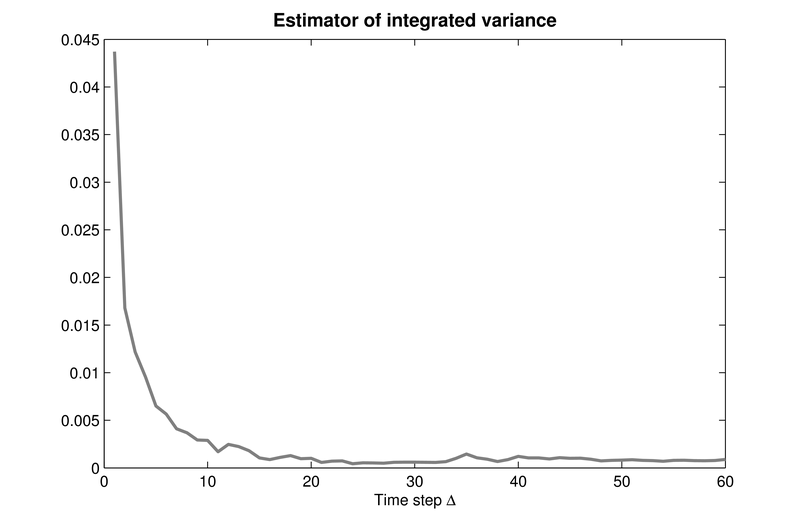

In [7]:
from IPython.display import Image
Image(filename='SignaturePlot.png', width=500)

_Estimator for the integrated variance computed for Rio Tinto between 03/01/2012 and 19/06/2012 according to the time discretization step._

They are many other ways to estimate the volatility: for example by using the minimum and the maximum of the price (see Garman & Klass), by considering multi-scale (see Ait-Sahalia or Ait-Sahalia & Jacod}) or by bid-ask modeling (see Robert & Rosenbaum).

**Observations and microstructure.** A model for log-price observation $X$ may be $X=M+\varepsilon$, where $M$ is a semi-martingale and $\varepsilon$ is the noise. Consequently
$$r_{\Delta}(j)=M_{\Delta j}-M_{\Delta(j-1)}+\varepsilon_{\Delta j}-\varepsilon_{\Delta(j-1)}=r^M_{\Delta}(j)+\eta_{\Delta}(j).$$
Thus the realized varince reads
$$\hat{V}_R(\Delta)=\sum_{j=1}^{T/\Delta}r_{\Delta}(j)^2=\sum_{j=1}^{T/\Delta}r^M_{\Delta}(j)^2+\sum_{j=1}^{T/\Delta}\eta_{\Delta}(j)^2+\sum_{j=1}^{T/\Delta}r^M_{\Delta}(j)\eta_{\Delta}(j).$$
This estimator diverges when $\Delta\to0$.

<font color='blue'>**To do.** Plot $\hat{V}_R(\Delta)$ with respect to $\Delta$ (in minutes and seconds) for all the assets. Do it for the mid-prices and the log-mid-prices. Comment the results.</font>

In [8]:
def Integrated_Variance(df_trades, delta, type_price="mid"):
    price = (df_trades["AskPrice"] + df_trades["BidPrice"])/2
    if type_price == "log":
        price = np.log((df_trades["AskPrice"] + df_trades["BidPrice"])/2)
    realized_variance = ((price.resample(delta).last().dropna().diff())**2).sum()
    return realized_variance

def MultiplePlot(function_realized_variance, type_price, maxdelta=12000):

    locs = list(Locations.keys())
    fig, axes = plt.subplots(4,3,figsize=(20, 10),constrained_layout=True)
    delta = [k for k in range(1,maxdelta,100)]
    for i,loc in enumerate(locs):
        cols=Locations[loc]
        for j in range(len(cols)):
            y = [function_realized_variance(dfs[cols[j]], str(delta_)+'s',type_price) for delta_ in delta]
            axes[j,i].plot(delta, y, label=cols[j])
            axes[j,i].legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
            axes[j,i].set_title(cols[j], fontsize=18,fontweight='bold', color="k")
            
    if (function_realized_variance == Integrated_Variance):
        fig.suptitle(f"Estimator of realized variance, {type_price} price", fontsize=24, color="darkblue",fontweight='bold')
    elif function_realized_variance == Garman_Klass_Integrated_Variance :
        fig.suptitle(f"Estimator of Garman Klass realized variance , {type_price} price", fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel("Delta (s)", fontsize=20, color="k")

    plt.show()
    
    
def ComparePlot(func1, func2, type_price, maxdelta=12000):
    locs = list(Locations.keys())
    fig, axes = plt.subplots(4,3,figsize=(20, 10),constrained_layout=True)
    delta = [k for k in range(1,maxdelta,100)]
    for i,loc in enumerate(locs):
        cols=Locations[loc]
        for j in range(len(cols)):
            y1 = [func1(dfs[cols[j]], str(delta_)+'s',type_price) for delta_ in delta]
            y2 = [func2(dfs[cols[j]], str(delta_)+'s',type_price) for delta_ in delta]
            axes[j,i].plot(delta, y1, label=func1.__name__)
            axes[j,i].plot(delta, y2, label=func2.__name__)
            axes[j,i].legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
            axes[j,i].set_title(cols[j], fontsize=18,fontweight='bold', color="k")
            
    
    fig.supxlabel("Delta (s)", fontsize=20, color="k")
    plt.show()
    

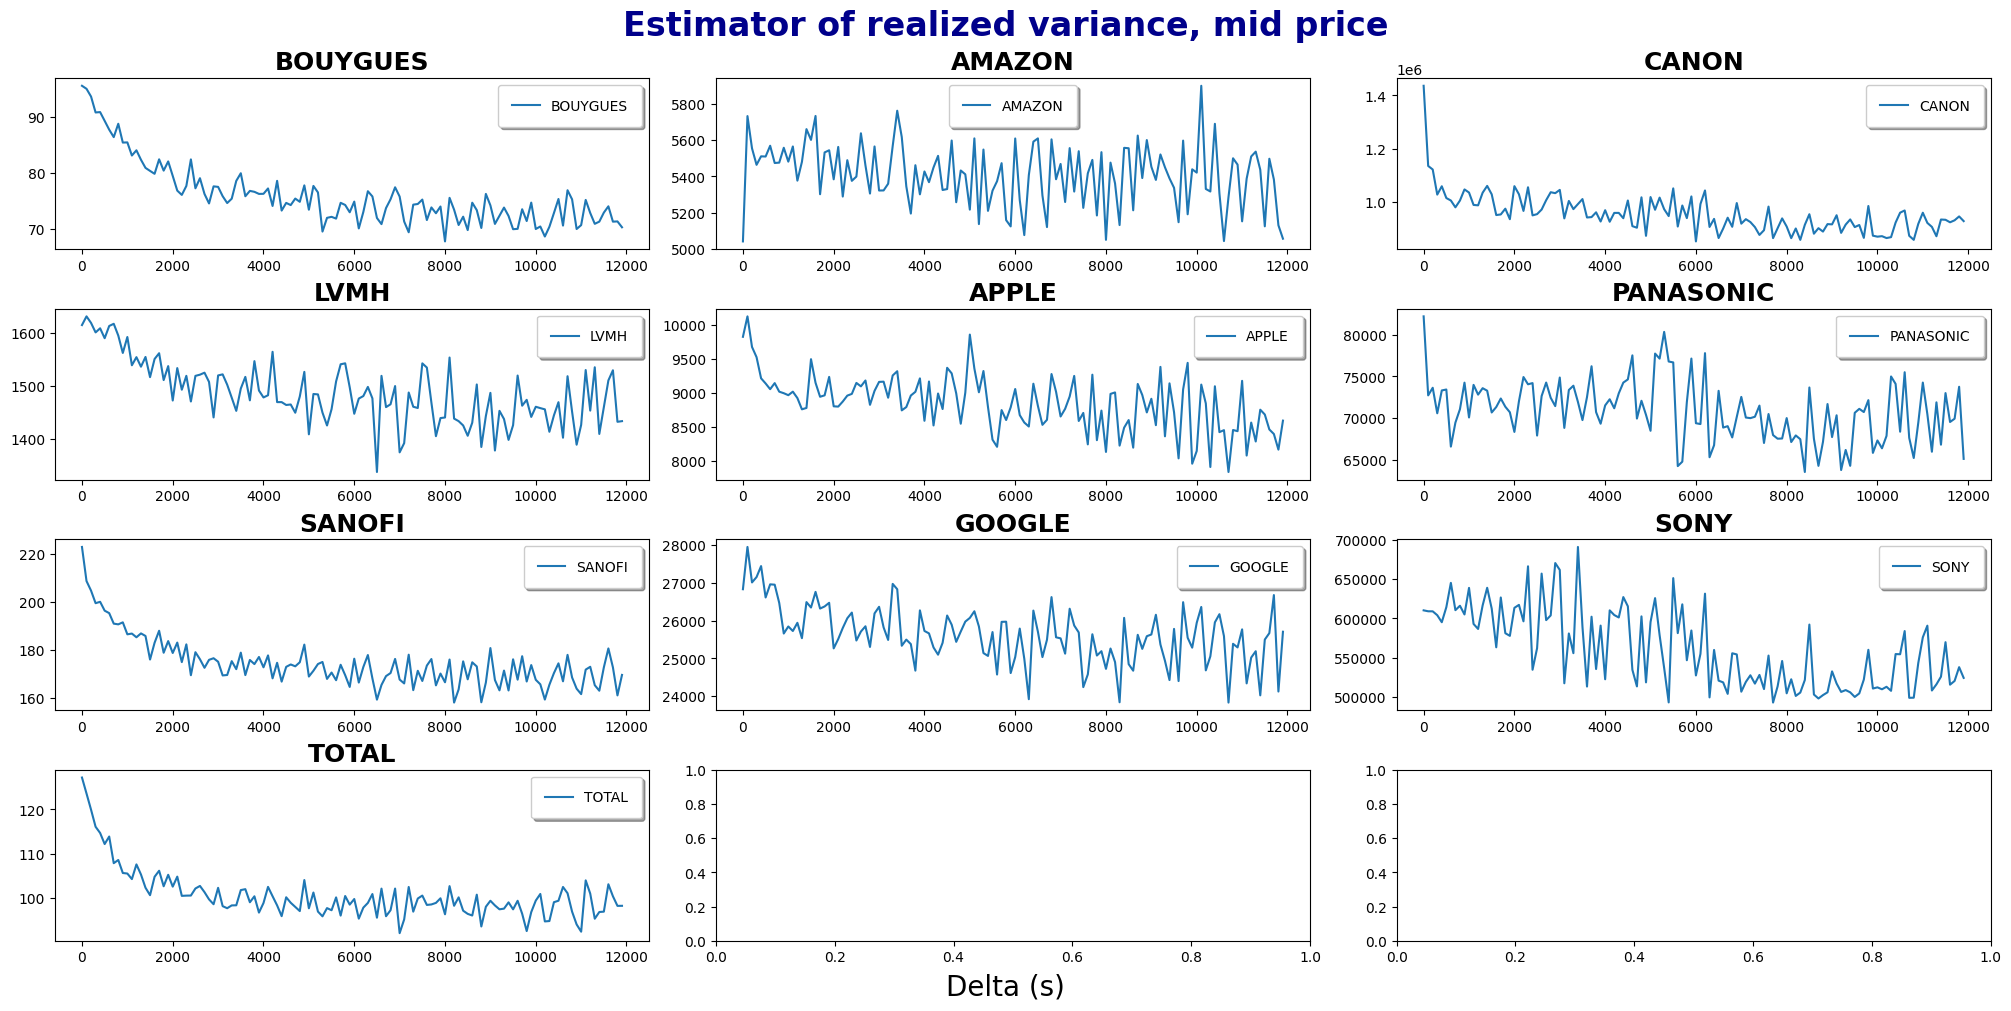

In [9]:
MultiplePlot(Integrated_Variance, 'mid')

From the graphs above, we can see that integrated volatility decreases with increasing time interval($\Delta T$). The signature plot property is therefore well verified by the real data (variance explodes when $\Delta \rightarrow 0$).

### 2. Intraday Volatility Estimator of Garman and Klass

They consider consider intraday volatility estimators that are based upon the historical opening, closing, high, and low prices and transaction volume. Since high and low prices require continuous monitoring to obtain, they correspondingly contain superior information content, exploited herein.

Their model assumes that a diffusion process governs security prices
$$P_t = \Phi(X_t)$$
where $P$ is the security price, $t$ is time, $\Phi$ is a monotonic, time-independent transformation, and $X_t$ is a diffusion process with the differential representation
$$dX_t = \sigma dW_t$$
where $W_t$ is the standard Brownian motion and $\sigma$ is an unknown constant to be estimated.

**"Best" Analytic Scale-invariant Estimators**

They consider estimators depending on
- the opening price,
- the closing price,
- the high price
- the low price.

For the authors, an estimator is "best" when it has minimum variance and is unbiased. They also impose the requirements that the estimators be analytic with price and time symmetries and scale-invariant. Under regularity condition (analytic in a neighborhood of the
origin), they obtain that the estimator must be quadratic in its arguments. Owing scale invariance and analyticity, they reduce the problem and find the "best" estimator of this form (unbiased with minimum variance). 

Finally, by eliminating the cross-product terms, the recommended and "more practical" estimator reads
$$\sigma_{GK}^2=\frac12\left(\mbox{High}-\mbox{Low}\right)^2-(2\ln2-1)\left(\mbox{Close}-\mbox{Open}\right)^2.$$

<font color='blue'>**To do.** 1. Compute the integrated variance with the Garman-Klass volatility estimator of both mid- and log-mid prices with respect to $\Delta$. Compare the results with the previous one.</font>

In [10]:
def Garman_Klass_Integrated_Variance(df_trades, delta, type_price="mid"):
    price = (df_trades["AskPrice"] + df_trades["BidPrice"])/2
    if type_price == "log":
        price = np.log(price)
    resampled_df = price.resample(delta).ohlc()
    resampled_df["GK estimator"] = 0.5*(resampled_df["high"] - resampled_df["low"])**2 - (2*np.log(2)-1)*(resampled_df["close"] - resampled_df["open"])**2
    GK_estimator = resampled_df["GK estimator"].sum()
    return GK_estimator

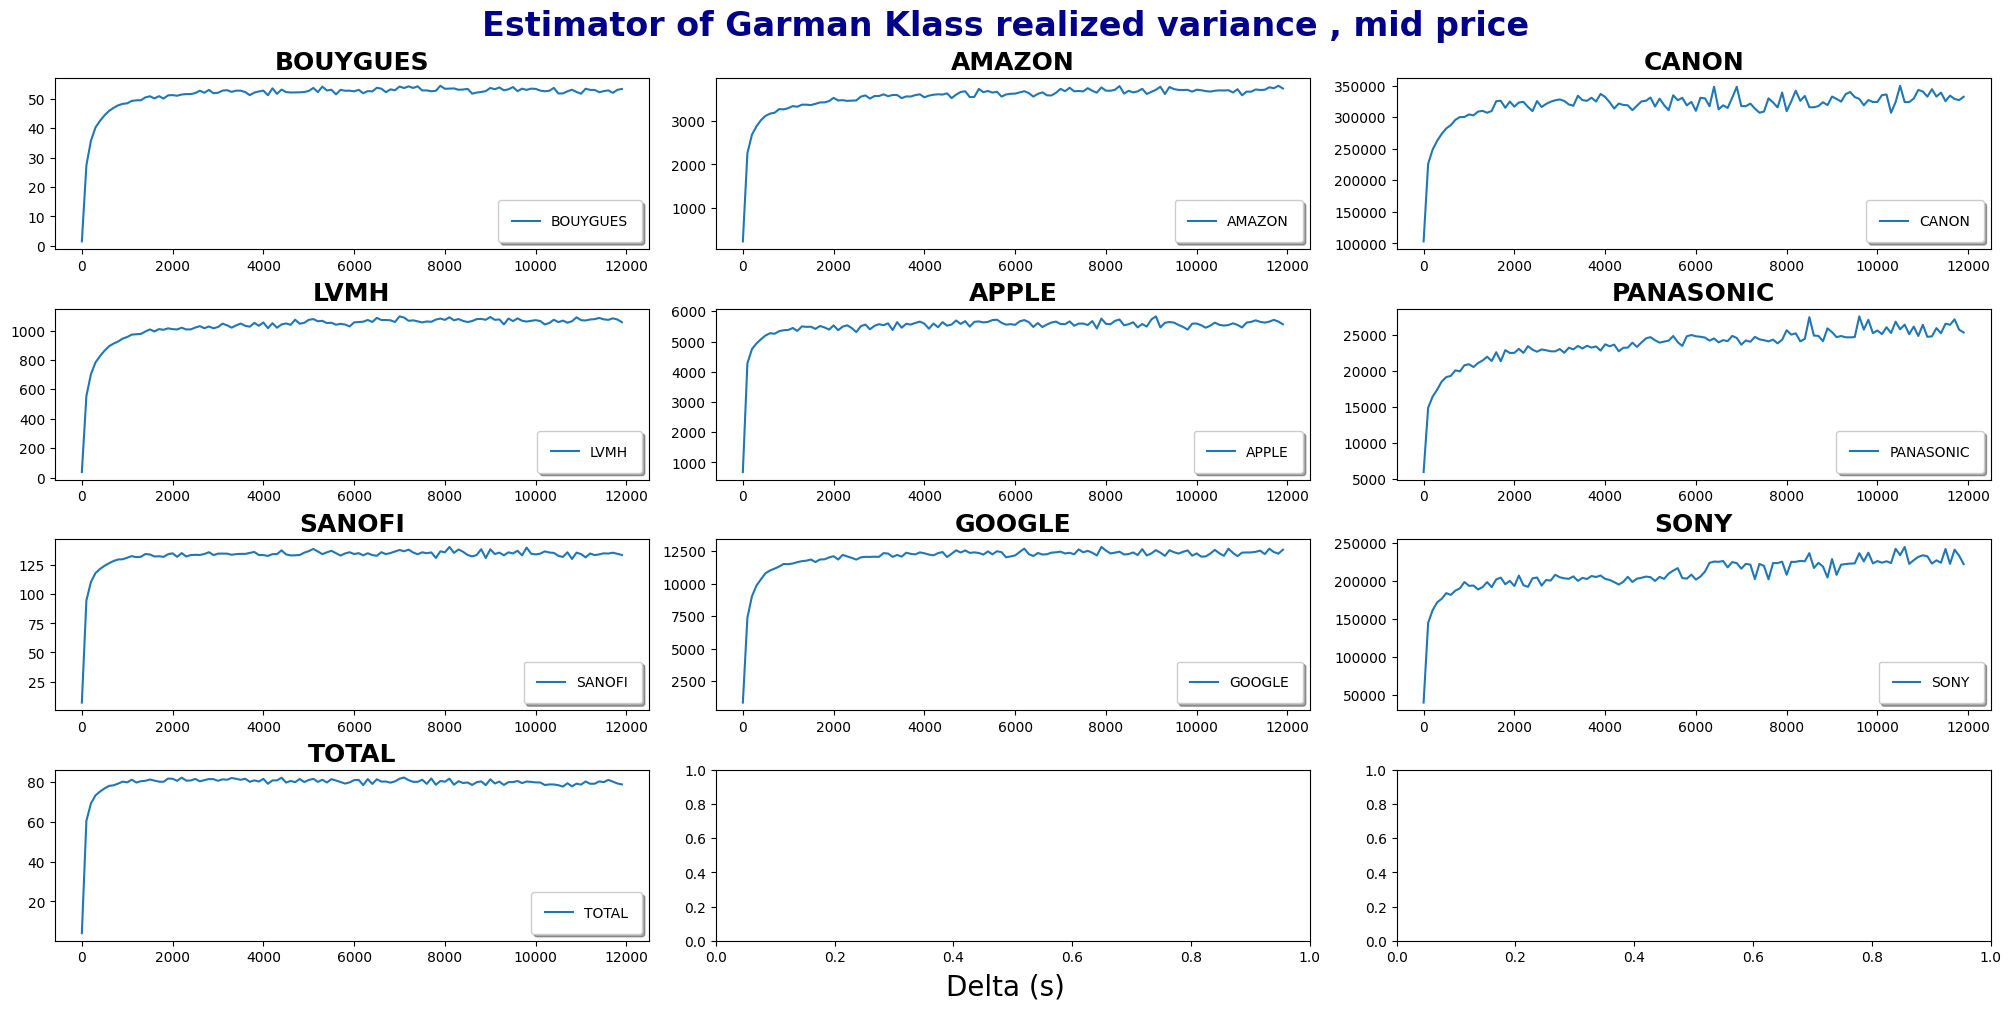

In [11]:
MultiplePlot(Garman_Klass_Integrated_Variance, 'mid')

We can see that for fairly low data frequencies (e.g. 60x24=1440 minutes, which represents a daily frequency), the variance estimated by the Garman-Klass estimator is very close to our 'natural' estimator defined in the previous section. This is very interesting, as the Garman-Klass estimator is based on only 4 data (OHLC), whereas the 'natural' estimator used all available data. It is therefore a good estimator if we don't have a lot of data.

<font color='blue'> 2. Compute the daily volatility with $\sigma_{GK}$ and $\hat{\sigma}$ (the standard deviation of the mid-price and log-mid-price). Compare and comment the results.</font>

In [12]:
def compute_garman_klass_vol_and_std_vol(type_price, stock):
    df_trades = dfs[stock]
    mid_price = (df_trades["AskPrice"] + df_trades["BidPrice"])/2
    if type_price == "log":
        mid_price = np.log(mid_price)
    resampled_df = mid_price.resample("1D").ohlc().dropna()
    resampled_df["GK estimator"] = np.sqrt(0.5*(resampled_df["high"] - resampled_df["low"])**2 - (2*np.log(2)-1)*(resampled_df["close"] - resampled_df["open"])**2)
    resampled_df["Std vol"]=std = np.sqrt(mid_price.resample('D').var()).apply(lambda x:np.nan if x <=0 else x).dropna()
    return resampled_df[["GK estimator", "Std vol"]].dropna()

def plot_garman_klass_vs_std(stock):

    fig, axes = plt.subplots(1,2,figsize=(20,5))
    df_mid = compute_garman_klass_vol_and_std_vol('mid',stock)
    df_mid.plot(ax = axes[0])
    axes[0].set_title('Mid price')
    
    df_log = compute_garman_klass_vol_and_std_vol('log',stock)
    df_log.plot(ax = axes[1])
    axes[1].set_title('Log price')

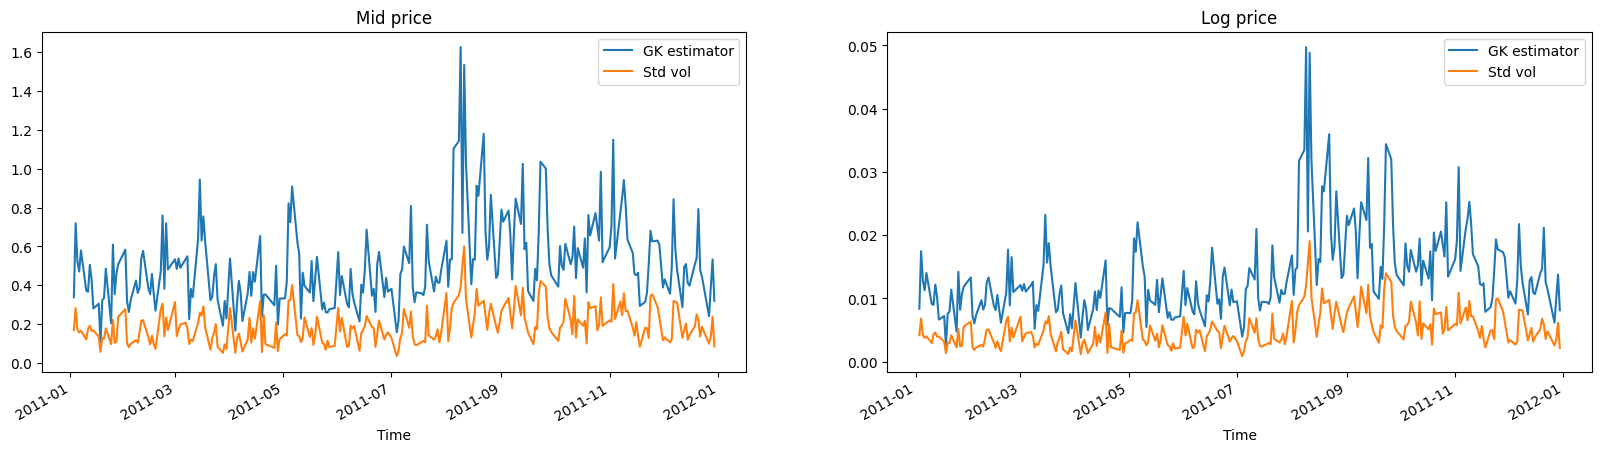

In [13]:
plot_garman_klass_vs_std(stock="TOTAL")

Daily volatility estimated by Garman-Klass has the same shape as daily volatility estimated by standard deviation.
The GK curve highlights days of high volatility, since its calculation formula involves the spread between extreme prices, as well as the difference between opening and closing prices.
In addition, the Garman-Klass curve shows the rough nature of volatility.

## II. Covariance Estimator and Epps Effect

### 1. "Classical" Covariance Estimator

Let $X^1= \log P^1$ and $X^2 = \log P^2$ be two log-price processes. 
$$d X^1 = \mu_t^1dt+\sigma_{t-}^1dW^1_t,$$
$$d X^2 = \mu_t^2dt+\sigma_{t-}^2dW^2_t,$$
with $d\left\langle W^1,W^2\right\rangle_t=\rho_tdt$.

Set for every $j\in{1,\ldots,T/\Delta}$, $r^1_{\Delta}(j)=X^1_{\Delta j}-X^1_{\Delta(j-1)}$ and $r^2_{\Delta}(j)=X^2_{\Delta j}-X^2_{\Delta(j-1)}$ the log-price increments.

Then the integrated covariance between the two assets reads
$$\int_0^T\rho_s\sigma^1_s\sigma^2_sds=\lim_{\Delta\to0}\sum_{j=1}^{T/\Delta}r^1_{\Delta}(j)r^2_{\Delta}(j).$$
Thus, an estimator for the realized covariance may be written as 
$$\hat{C}_R(\Delta)=\sum_{j=1}^{T/\Delta}r^1_{\Delta}(j)r^2_{\Delta}(j).$$ 
This estimator is consistent since 
$$\hat{C}_R(\Delta)\overset{\mathbb{P}}{\underset{\Delta\to0}{\longrightarrow}}\int_0^T\rho_s\sigma^1_s\sigma^2_sds.$$ 

The problem is that we must have synchronous data, but the quotations and transactions are asynchronous.

### 2. Previous Tick Estimator

Assume now that we observe $P^1$ at times $(T^1_j)_{j\geq1}$ and $P^2$ at times $(T^2_j)_{j\geq1}$. Therefore we design 
$$\bar{P}^1_t=P_{T^1_j} \quad\mbox{for }t\in[T^1_j,T^1_{j+1})$$
and
$$\bar{P}^2_t=P_{T^2_j} \quad\mbox{for }t\in[T^2_j,T^1_{j+1}).$$
Then 
$$\bar{X}^1_t=\log \bar{P}^1_t \quad\mbox{and}\quad\bar{X}^2_t=\log \bar{P}^2_t/$$

For a given $\Delta$, the previous tick covariation estimator is
$$\bar{C}_R(\Delta)=\sum_{j=1}^{T/\Delta}\left(\bar{X}^1_{\Delta j}-\bar{X}^1_{\Delta (j-1)}\right)\left(\bar{X}^2_{\Delta j}-\bar{X}^2_{\Delta (j-1)}\right).$$

### 3. Epps Effect

Epps (1979): "Correlations among price changes [...] are found to decrease with the length of the interval for which the price changes are measured."
Many explanations were proposed
- systematic bias for this estimator,
- "lead-lag" effect for the assets in the same sector,
- asynchronicity of transactions,
- "tick" effect and other microstructure effects.

**Example.** Assume that $X^1$ and $X^2$ are two Brownian motions with correlation $\rho$ and the trade times are arrival times of two independent Poisson processes. Then, one can show that
$$\mathbb{E}[\bar{C}_R(\Delta)]\underset{\Delta\to0}{\longrightarrow}0.$$

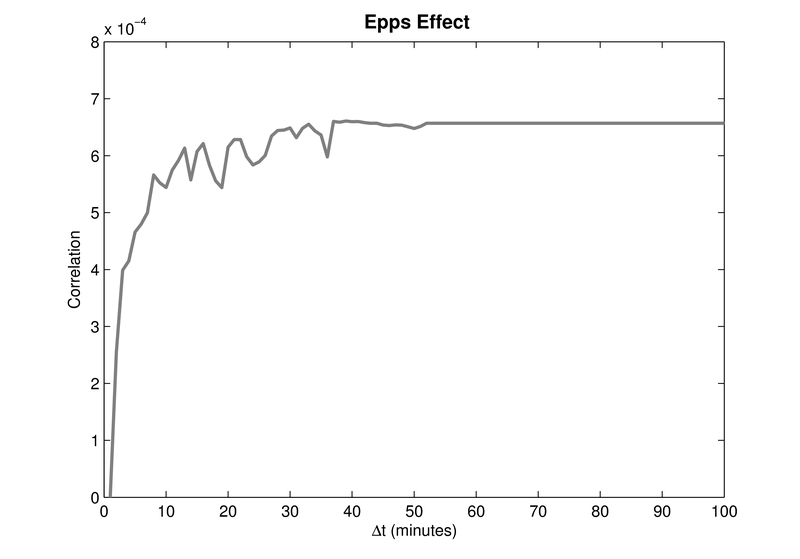

In [14]:
Image(filename='EppsEffect.png', width=500)

_Estimator for the correlation between Total and France Telecom on Euronext Paris on the period from 23/07/2012 to 27/07/2012 as a function of time discretization step._

<font color='blue'>**To do.** Plot the correlation with respect to $\Delta$ (in minutes or seconds) for couples of asset on the same exchange (using the mid-price and the log-mid-price). Comment the results.</font>

In [15]:
def compute_realized_corr(type_price="mid", exchange="Paris"):
        
    locs=Locations[exchange]
    n=len(locs)
    if n==4:
        m=6
    elif n==3:
        m=3
    delta =  [k for k in range(1,12000,100)]
    fig, axes = plt.subplots(m//3,3,figsize=(22, 10),constrained_layout=True)      
    count1 = 0
    count2 = 0
    for i in range(n):
        for j in range(i):
            stock1 = locs[i]
            stock2 = locs[j]
            if stock1 != stock2 :
                realized_corr_s1_s2 =[]
                for delta_ in delta :
                    if type_price=="mid" :
                        price_stock1 = ((dfs[stock1]["AskPrice"] + dfs[stock1]["BidPrice"])/2).resample(str(delta_)+'s').last().fillna(method='ffill').diff()
                        price_stock2 = ((dfs[stock2]["AskPrice"] + dfs[stock2]["BidPrice"])/2).resample(str(delta_)+'s').last().fillna(method='ffill').diff()
                    elif type_price == "log":
                        price_stock1 = (np.log((dfs[stock1]["AskPrice"] + dfs[stock1]["BidPrice"])/2)).resample(str(delta_)+'s').last().fillna(method='ffill').diff()
                        price_stock2 = (np.log((dfs[stock2]["AskPrice"] + dfs[stock2]["BidPrice"])/2)).resample(str(delta_)+'s').last().fillna(method='ffill').diff()      
                    
                    realized_cov_s1_s2 = (price_stock1*price_stock2).sum() 
                    std1 = np.sqrt((price_stock1**2).sum())
                    std2 = np.sqrt((price_stock2**2).sum())
                    realized_corr_s1_s2.append(realized_cov_s1_s2 / (std1 * std2))
                
                axes[count1,count2].plot(delta,realized_corr_s1_s2)
                axes[count1,count2].grid(True)
                axes[count1,count2].set_facecolor('xkcd:white')
                axes[count1,count2].set_title(stock1 + " - " + stock2, fontsize=18,fontweight='bold', color="k")
                count2+=1
                if count2 > 2:
                    count1 +=1
                    count2 =0
            
    fig.suptitle("Epps Effect", fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel("delta (s)", fontsize=20, color="k")
    fig.supylabel("Correlation", fontsize=20, color="k")
    plt.show()



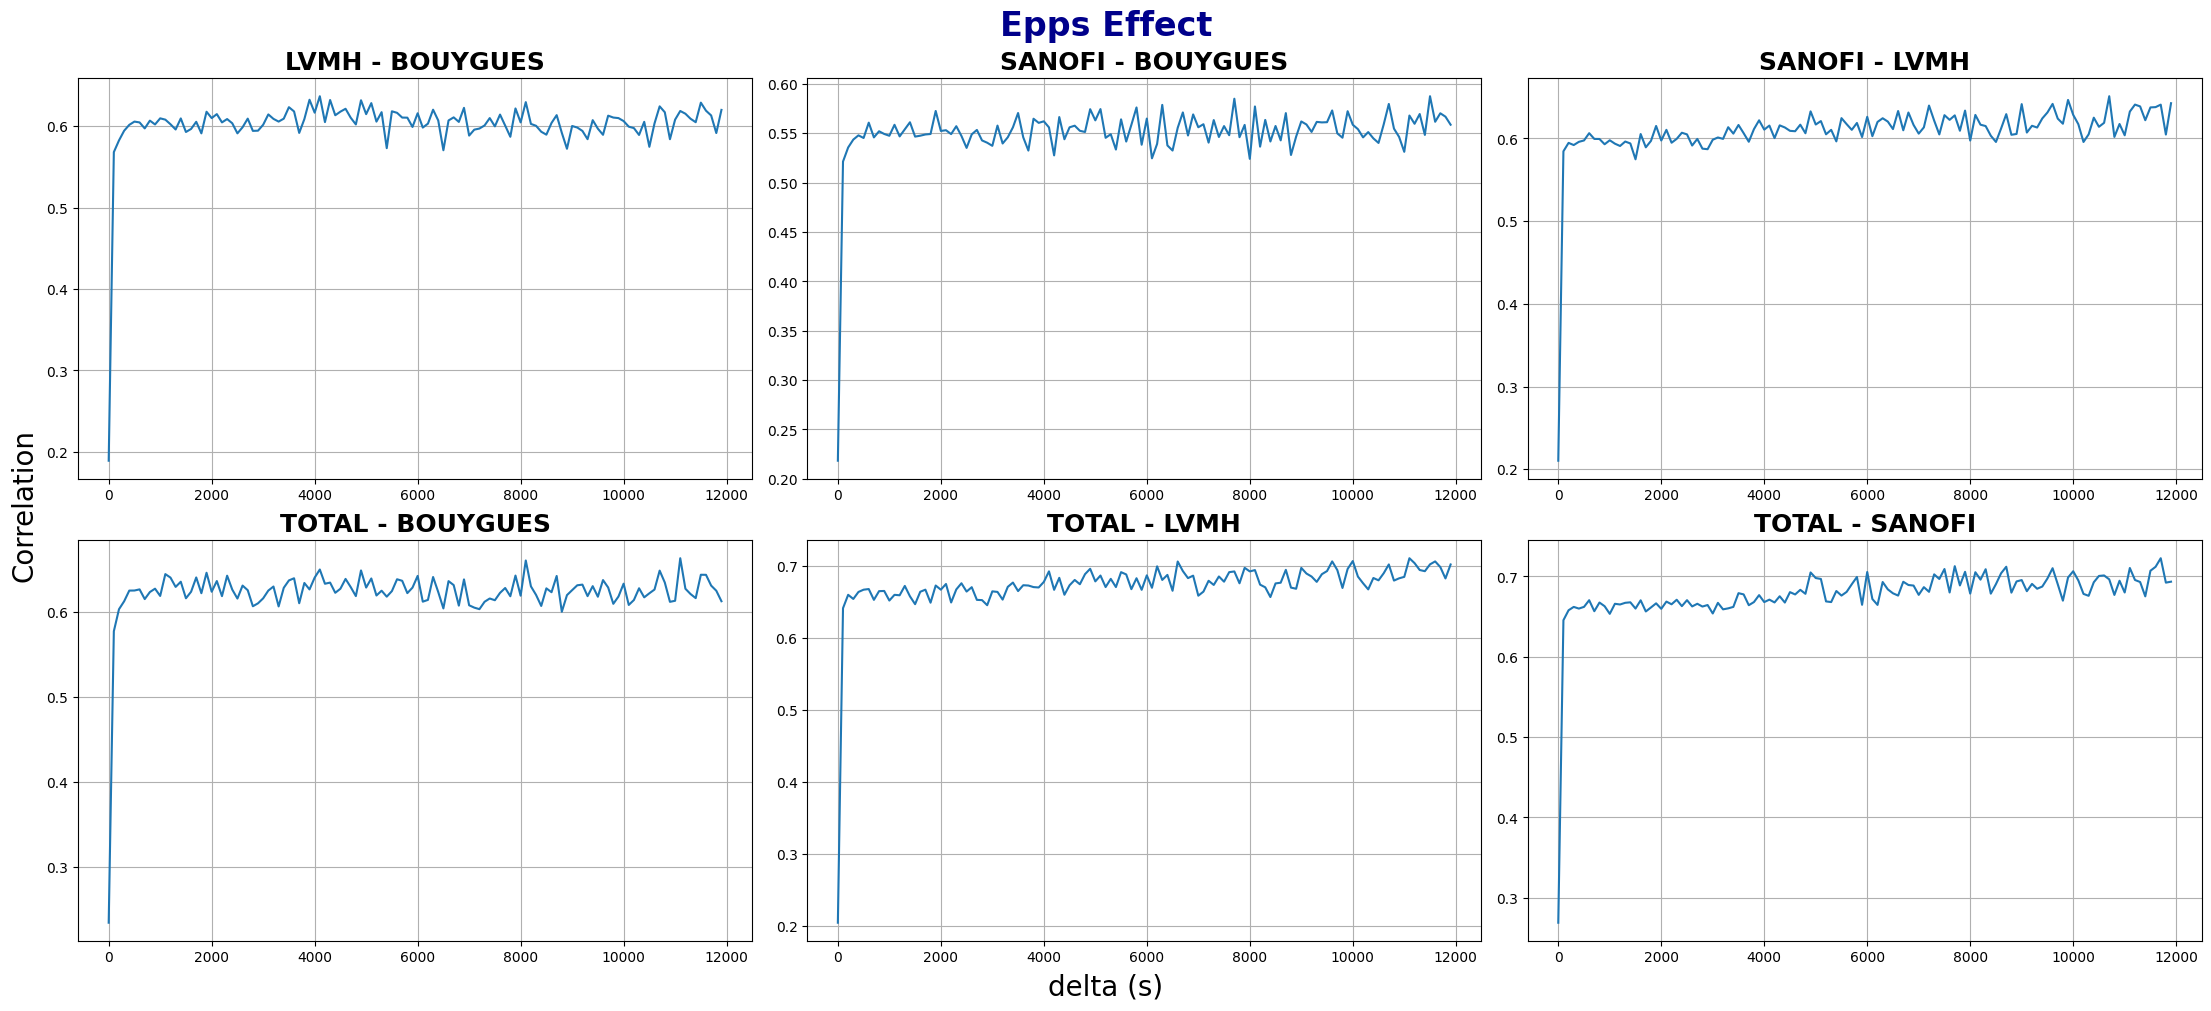

In [16]:
compute_realized_corr(type_price="log", exchange="Paris")

The Epps effect is well reproduced in the graphs. Covariance decreases as Delta decreases.

The correlation estimator for high-frequency data is studied in many publications, for example Hayashi & Yoshida or Zhang.

### 4. Hayashi-Yoshida Estimator

Let $I^1_i=(T^1_i,T^1_{i+1}]$, $i\geq1$, and $I^2_j=(T^2_j,T^2_{j+1}]$, $j\geq1$.

The cumulative covariance estimator of Hayashi-Yoshida reads
$$U_n=\sum_{i,j}\Delta P^1(I^1_i)\Delta P^2(I^2_j)\mathbb{1}_{\{I^1_i\cap I^2_j\neq\emptyset\}}.$$

That is, the product of any pair of increments $\Delta P^1(I^1_i)$ and $\Delta P^2(I^2_j)$ will make a contribution to the summation only when the respective observation intervals $I^1_i$ and $I^2_i$ are overlapping.

This estimator does not need any selection of $\Delta$ and is convergent if the arrival times are independent from the price.

Then, they define two associated correlation estimators
- if $\sigma_1$ and $\sigma_2$ are known,
$$R^1_n=\frac1T\frac{\sum_{i,j}\Delta P^1(I^1_i)\Delta P^2(I^2_j)\mathbb{1}_{\{I^1_i\cap I^2_j\neq\emptyset\}}}{\sigma_1\sigma_2},$$
- if $\sigma_1$ and $\sigma_2$ are known/unknown,
$$R^2_n=\frac{\sum_{i,j}\Delta P^1(I^1_i)\Delta P^2(I^2_j)\mathbb{1}_{\{I^1_i\cap I^2_j\neq\emptyset\}}}{\sqrt{\sum_i\Delta P^1(I^1_i)^2}\sqrt{\sum_j\Delta P^2(I^2_j)^2}}.$$
Under the same conditions as for $U_n$, $R^1$ and $R^2$ are consistent for $\rho$ as $n\to\infty$.

**Remarque.** This estimator is nevertheless not robust to microstructure effects.

<font color='blue'>**To do.** Compute the daily Hayashi-Yoshida estimator for couples of assets on the same exchange and compare it to classical estimator. Do it for one month you choose and plot the results. Comment. </font>

We will use the first month as an example

In [17]:
def Hayashi_Yoshida(stock1, stock2):
    
    fig, ax = plt.subplots(figsize=(22, 10),constrained_layout=True) 
    
    df_trades_1 = dfs[stock1]
    df_trades_1.loc[:, "Date"] = df_trades_1.index.date
    df_trades_1.loc[:, "Month"] = df_trades_1.index.month
    df_trades_1 = df_trades_1.reset_index().drop_duplicates(subset=["Time"]).set_index(keys=['Month', 'Date', 'Time']).loc[1]
    df_trades_2 = dfs[stock2]
    df_trades_2.loc[:, "Date"] = df_trades_2.index.date
    df_trades_2.loc[:, "Month"] = df_trades_2.index.month
    df_trades_2 = df_trades_2.reset_index().drop_duplicates(subset=["Time"]).set_index(keys=['Month', 'Date', 'Time']).loc[1]
    
    rhos_HY_determ = []
    rhos_IC = []
    
    for date in df_trades_1.index.unique(level = 0):
        df_trades_date_1, df_trades_date_2 = df_trades_1.loc[date], df_trades_2.loc[date]
        PriceSec1 = df_trades_date_1['TradedPrice'].resample('1s').first().fillna(method='ffill')
        PriceSec2 = df_trades_date_2['TradedPrice'].resample('1s').first().fillna(method='ffill')
        rhos_IC.append(PriceSec1.corr(PriceSec2))
    

    for date in df_trades_1.index.unique(level=0):
        cov, var1, var2 = 0, 0, 0
        df_trades_1_date = df_trades_1.loc[date].loc[:, ["TradedPrice"]].fillna(method="ffill")
        df_trades_2_date = df_trades_2.loc[date].loc[:, ["TradedPrice"]].fillna(method="ffill")

        df_trades_1_date.TradedPrice = np.log(df_trades_1_date.TradedPrice)
        df_trades_2_date.TradedPrice = np.log(df_trades_2_date.TradedPrice)

        j = 0
        while df_trades_2_date.index[j] < df_trades_1_date.index[0]:
            j += 1
        for i in range(1, df_trades_1_date.shape[0]):
            while j + 1 < df_trades_2_date.shape[0] and df_trades_2_date.index[j] < df_trades_1_date.index[i]:
                cov += (df_trades_2_date.iloc[j + 1, 0] - df_trades_2_date.iloc[j, 0])*(df_trades_1_date.iloc[i, 0] - df_trades_1_date.iloc[i - 1, 0])
                j += 1

        var1 = df_trades_1_date.TradedPrice.diff().pow(2).sum()
        var2 = df_trades_2_date.TradedPrice.diff().pow(2).sum()

        rhos_HY_determ.append(cov / np.sqrt(var1 * var2))

    
    plt.plot(df_trades_1.index.unique(level=0), rhos_IC, marker='o', label="Classical estimator", drawstyle="steps-mid")
    plt.plot(df_trades_1.index.unique(level=0), rhos_HY_determ, marker='o', label="HY estimator", drawstyle="steps-mid")

    plt.legend(shadow=True, fancybox=True)
    plt.xlabel("Date")
    plt.ylabel("Correlation")         
    plt.title("Comparaison des estimateurs de la correlation pour " + stock1 + " - " + stock2, fontsize=24, color="darkblue",fontweight='bold')
    plt.show()
    

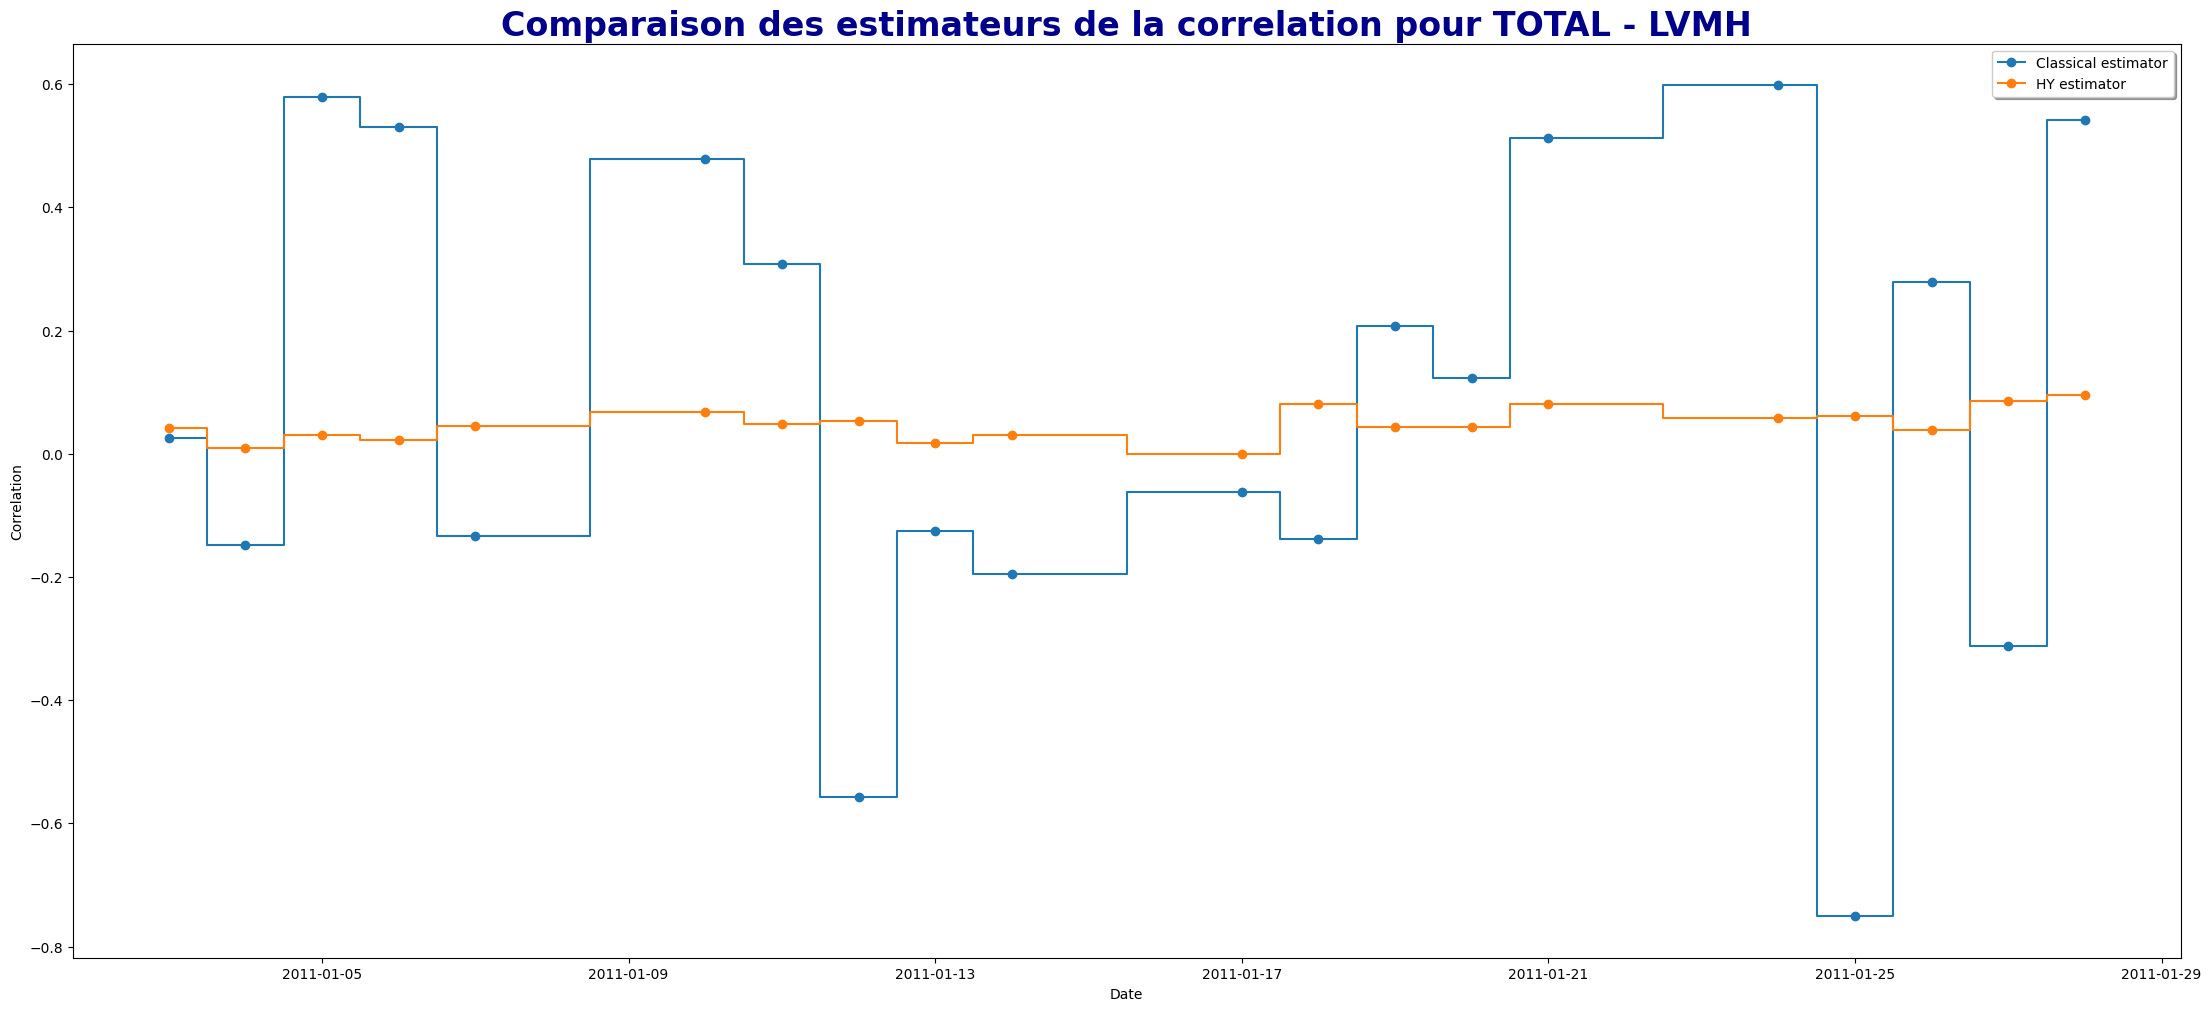

In [18]:
Hayashi_Yoshida("TOTAL", "LVMH")

We observe that the classical estimator has a much larger variance than the Hayashi-Yoshida estimator, and is much more biased towards trading days.

## III. Link between bid-ask spread and volatility per trade for large tick assets

Dayri and Rosenbaum developed a new approach to exhibit the relationship between bid-ask spread and volatility per trade for large tick assets. The model derives from the one with uncertainty zones. They assume the existence of a latent price representing the opinion of market participants on the ``true'' price and modeled by a continuous Brownian semi-martingale $(x_t)_{t\geq0}$. Let $\alpha$ be the tick size of the asset. The areas of uncertainty are defined as bands around the middle of the tick size with width $2\eta\alpha$, $0<\eta<1$. The dynamics of the price of the last transaction $p_t$ is obtained as a function of the latent price and areas of uncertainty. The bid-ask spread is assumed to be constant and equal to the tick size $\alpha$. 

The authors define alternating (resp. continuity) of a tick size as a jump in the price of a tick size whose direction is adverse (resp. the same) than the previous jump. The number of alternations and continuities of a tick size are denoted by $N_{\alpha,t}^{(a)}$ and $N_{\alpha,t}^{(c)}$ respectively on the period $[0,t]$. The consistent estimator of $\eta$ on $[0,t]$ is then
$$\widehat{\eta}_{\alpha,t}=\frac{N_{\alpha,t}^{(c)}}{2N_{\alpha,t}^{(a)}}.$$
For volatility, first note that this model allows to find the value of the latent price on the date of $\tau_i$ of the $i^{th}$ price change by the simple relationship
$$x_{\tau_i}=p_{\tau_i}-\mbox{sign}\left(p_{\tau_i}-p_{\tau_{i-1}}\right)\left(\frac12-\eta\right)\alpha.$$
As we can estimate $\eta$, we can then find out $x_{\tau_i}$ from $p_{\tau_{i-1}}$ and $p_{\tau_i}$. For example, the realized variance on estimated values of the efficient price on $[0,t]$
$$\widehat{\sigma^2_{LP,t}}=\sum_{\tau_i\leq t}\left(\widehat{x}_{\tau_i}-\widehat{x}_{\tau_{i-1}}\right)^2,$$
where $\widehat{x}_{\tau_i}=p_{\tau_i}-\mbox{sign}\left(p_{\tau_i}-p_{\tau_{i-1}}\right)\left(\frac12-\widehat{\eta}_{\alpha,t}\right)\alpha$, is an estimator of the integrated variance of the latent price over $[0,t]$ $\int_0^t\sigma_s^2ds$. Now we set $\widehat{\sigma}_{LP}=\sqrt{\widehat{\sigma^2_{[0,t]}}}$ and we define the volatility per trade by $\widehat{\sigma}_{LP}/\sqrt{N}$ where $N:=N_{[0,t]}$ denotes the total number of trades on $[0,t]$. Without making any differences between parameters and their estimates, we get then the following relationship

\begin{equation}
\eta \alpha \approx c \frac{\sigma_{LP}}{\sqrt{N}}.
\end{equation}


Market participants have a certain resolution, or precision at which they infer the efficient price $x_t$. $\eta$ quantifies this resolution: when $\eta$ is close to 1/2, the resolution is close to the tick value. The quantity $2\eta\alpha$ can be seen as an implicit spread: $\eta$ can indeed be viewed as a suitable measure for the tick size.


<font color='blue'>**To do.** 1. Compute $\eta$, $\alpha$ and $\sigma_{LP}$ on a daily basis for each asset. Compare the implicit spread and the real spread. Idem for the volatilities of both latent price and traded price. Comment.</font>

In [19]:
def calcul_alpha(stock):
    alpha = stock['Spread'].resample('D').mean()
    alpha = alpha.dropna()
    return alpha

def calcul_eta(stock):
    stock['MidP+1'] = stock['MidPrice'].shift(1)
    stock['MidP+2'] = stock['MidPrice'].shift(2)
    direc = ((stock['MidPrice'] - stock['MidP+1'])*(stock['MidP+1']-stock['MidP+2'])).apply(np.sign).dropna()
    direc = direc.resample('D')
    s = direc.count()
    abso = direc.sum()
    alter = (s - abso)/2
    conti = (s + abso)/2
    ita = (conti/(2*alter)).apply(lambda x:min(x,0.5))
    ita = ita.apply(lambda x:np.nan if x <=0 else x).dropna()
    return ita

    
def calcul_vol_latent(stock,alpha,ita):
    alpha_m = alpha.mean()
    ita_m = ita.mean()
    stock['X'] = stock['MidPrice'] - (stock['MidPrice'] - stock['MidP+1']).apply(np.sign) * alpha_m*(0.5 - ita_m)
    diff_somme = ((stock['X'] - stock['X'].shift(-1))**2).dropna()
    vol = diff_somme.resample('D').sum().apply(lambda x:np.nan if x <=0 else x).dropna()
    return vol


In [20]:
def plot_Spread():
    fig, axes = plt.subplots(4,3,figsize=(20, 10),constrained_layout=True)
    
    locs = list(Locations.keys())
    for i,loc in enumerate(locs) :
        cols=Locations[loc]
        for j,col in enumerate(cols):
            stock  = dfs[col]
            stock['MidPrice'] = (stock['BidPrice'] + stock['AskPrice'])/2
            stock['Spread'] = stock['AskPrice'] - stock['BidPrice']
            TradeNums = stock['MidPrice'].resample('D').count().apply(lambda x:np.nan if x <=0 else x).dropna()

            alpha = calcul_alpha(stock)
            stock = stock[stock['MidPrice'] != stock['MidPrice'].shift(1)]
            eta = calcul_eta(stock)
            im_alpha = 2*eta*alpha
            axes[j,i].plot(alpha,'*',label = col + ' Real Spread')
            axes[j,i].plot(im_alpha,'-',label = col + ' Implicit Spread')
            axes[j,i].legend(shadow=True, fancybox=True)
            axes[j,i].grid(True)
            axes[j,i].set_facecolor('xkcd:white')
            axes[j,i].set_title(col, fontsize=18,fontweight='bold', color="k")
            
    fig.suptitle("Relation entre le Spread réel et le Spread implicite", fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel("Date", fontsize=20, color="k")
    fig.supylabel("Spread", fontsize=20, color="k")
    plt.show()



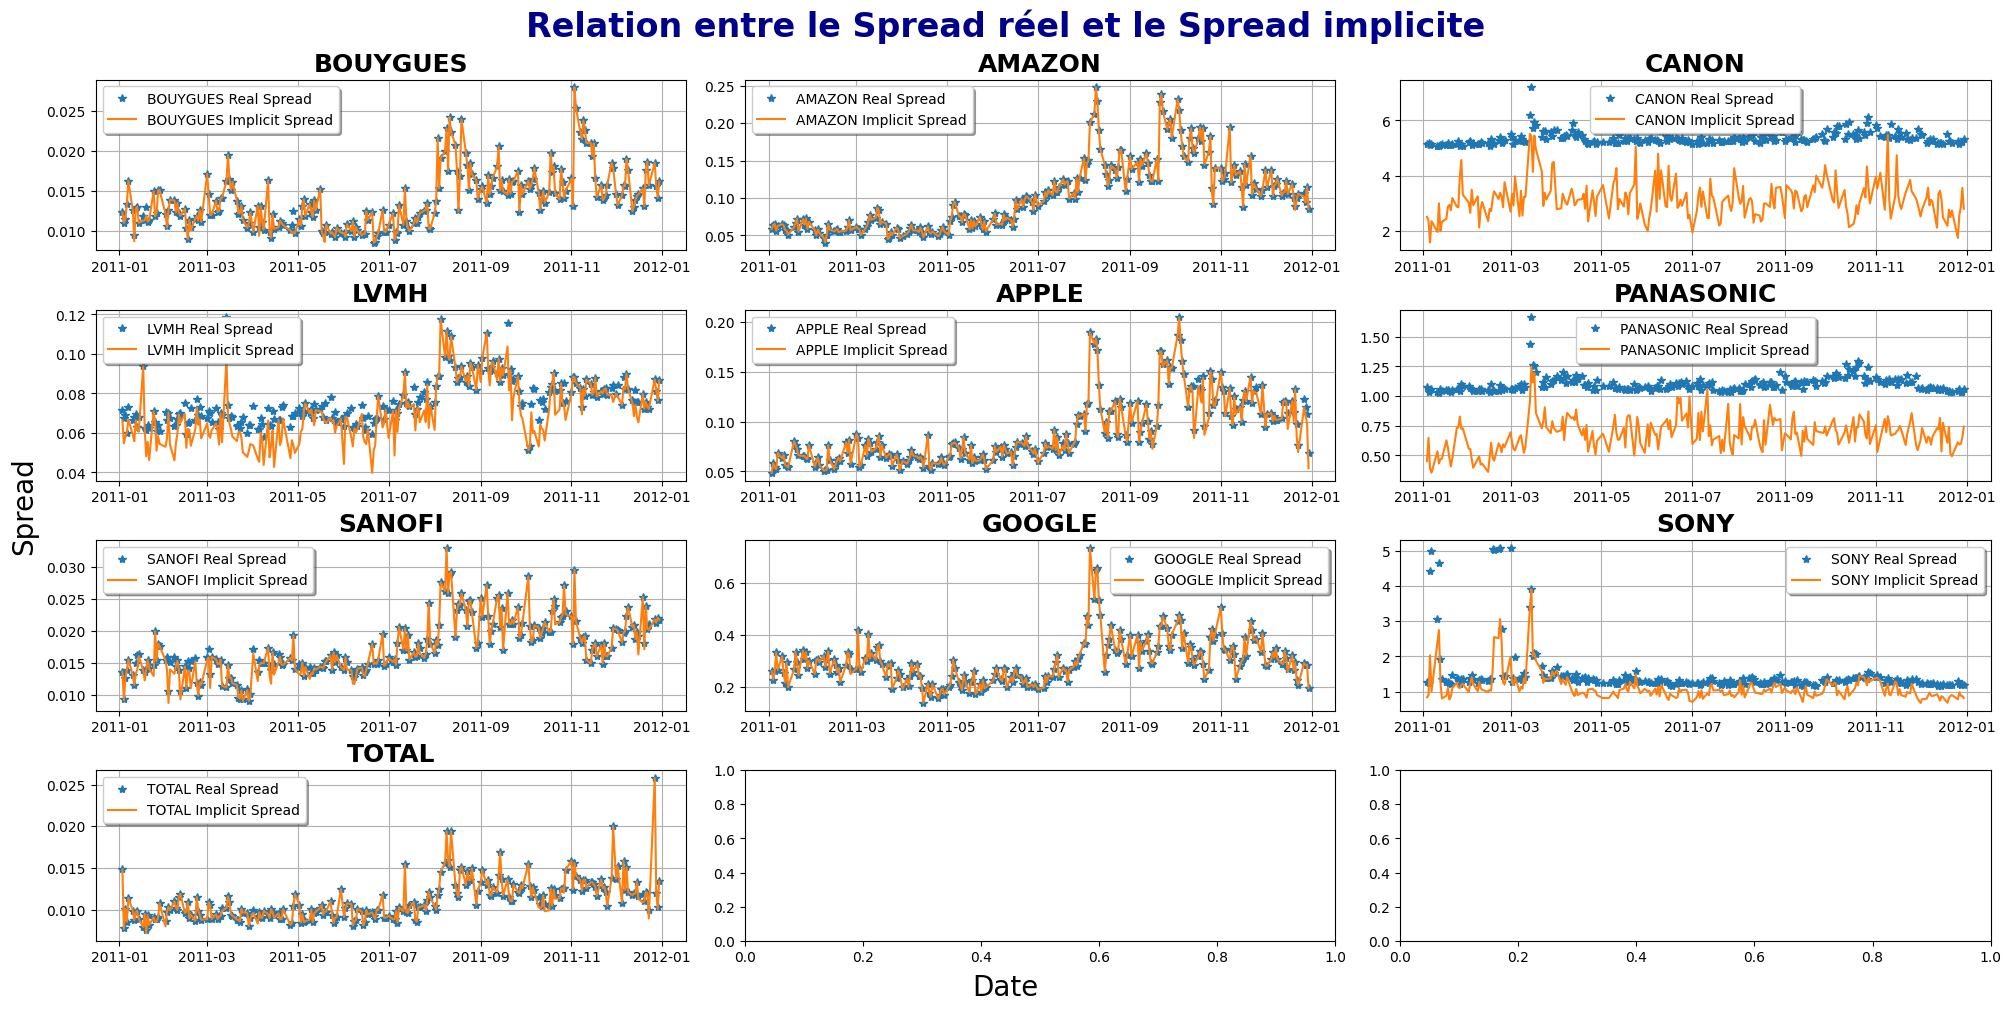

In [21]:
plot_Spread()

In [22]:
def plot_vol():
    fig, axes = plt.subplots(4,3,figsize=(20, 10),constrained_layout=True)
    
    locs = list(Locations.keys())
    for i,loc in enumerate(locs) :
        cols=Locations[loc]
        for j,col in enumerate(cols):
            stock  = dfs[col]
            stock['MidPrice'] = (stock['BidPrice'] + stock['AskPrice'])/2
            stock['Spread'] = stock['AskPrice'] - stock['BidPrice']
            TradeNums = stock['MidPrice'].resample('D').count().apply(lambda x:np.nan if x <=0 else x).dropna()

            alpha = calcul_alpha(stock)
            stock = stock[stock['MidPrice'] != stock['MidPrice'].shift(1)]
            eta = calcul_eta(stock)
            vol = calcul_vol_latent(stock,alpha,eta)
    
            diff_somme = ((stock['MidPrice'] - stock['MidPrice'].shift(-1))**2).dropna()
            vol_tr = diff_somme.resample('D').sum().apply(lambda x:np.nan if x <=0 else x).dropna()
            axes[j,i].plot(vol,'*',label = col + ' latent price')
            axes[j,i].plot(vol_tr,'.',label = col + ' traded price')
            axes[j,i].legend(shadow=True, fancybox=True)
            axes[j,i].grid(True)
            axes[j,i].set_facecolor('xkcd:white')
            axes[j,i].set_title(col, fontsize=18,fontweight='bold', color="k")
            
    fig.suptitle("Relation entre les volatilités calculée à partir du latent price et du traded price", fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel("Date", fontsize=20, color="k")
    fig.supylabel("Volatilité", fontsize=20, color="k")
    plt.show()


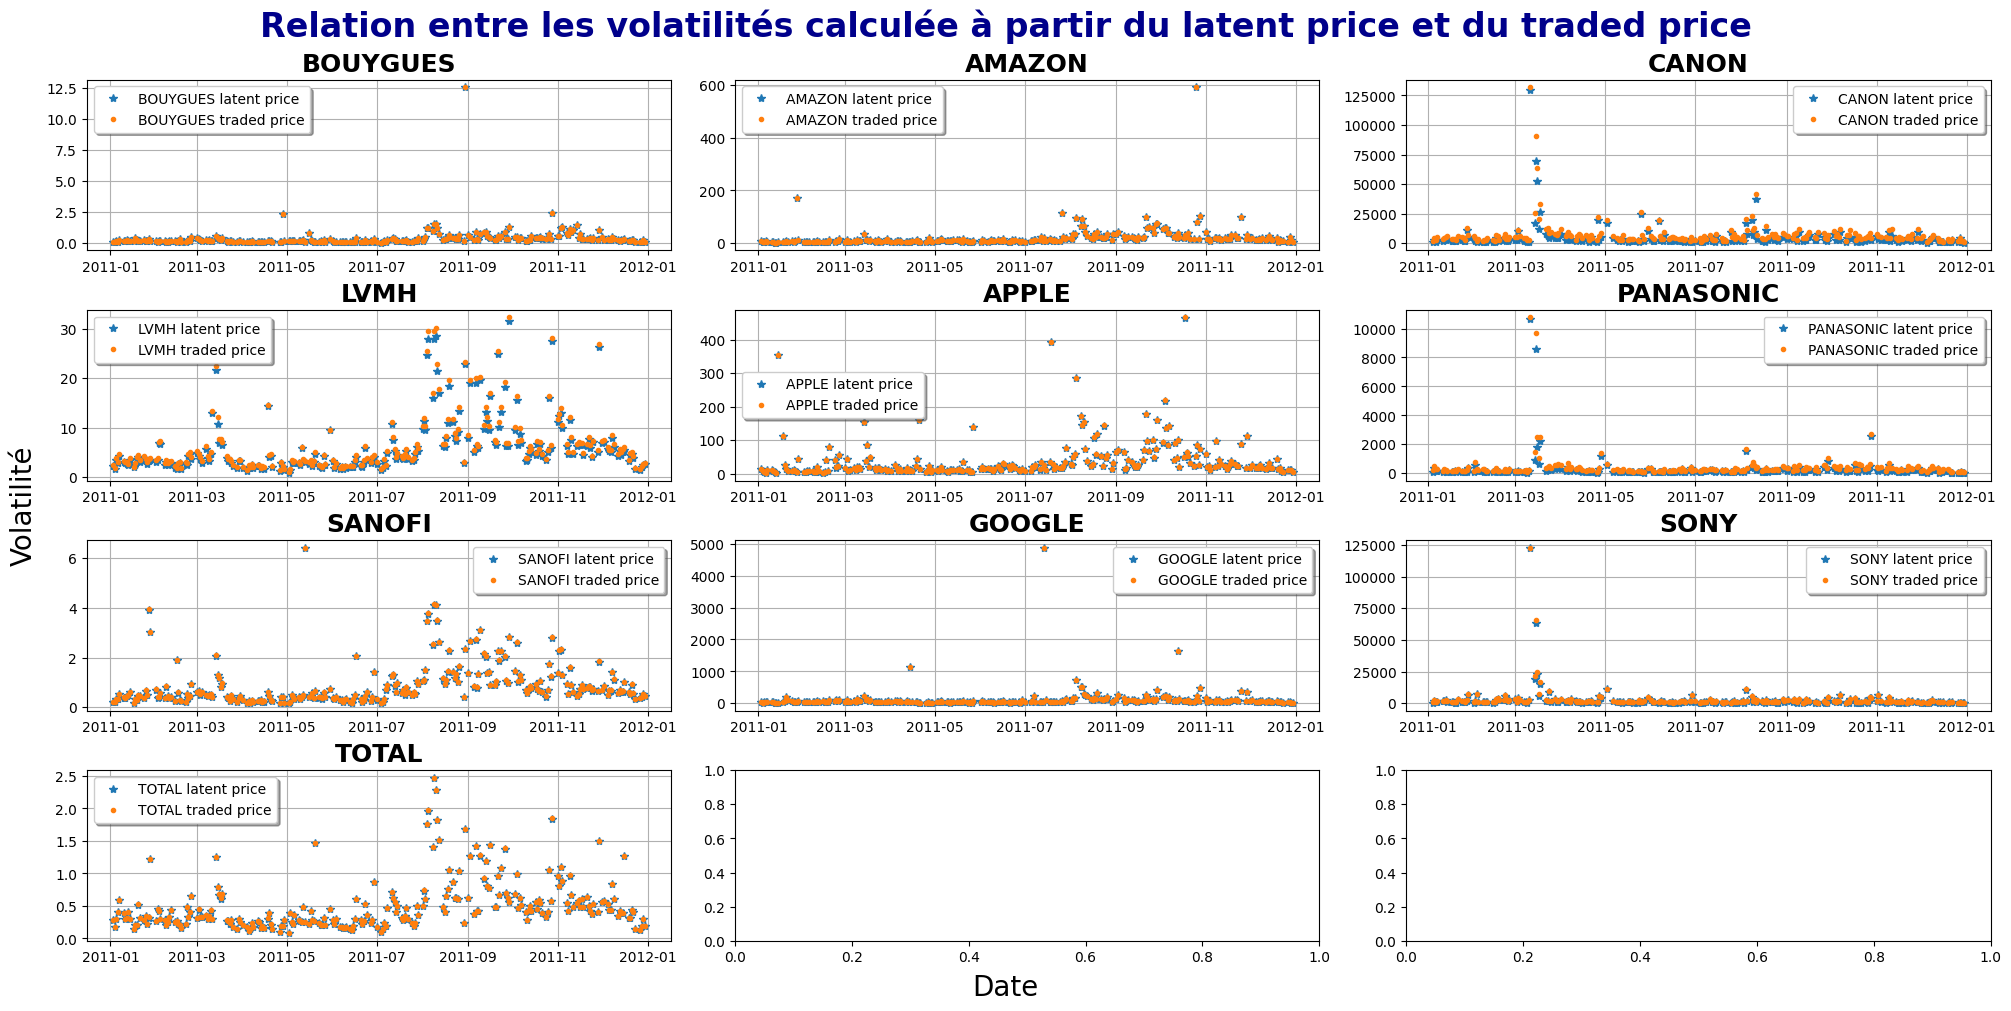

In [23]:
plot_vol()

We can observe that, in line with the fact that Japanese assets are large tick assets, the spread is very often equal to 1 tick.

The volatility of the latent price has exactly the same shape as that of the traded price, which is good news for the uncertainty zone model. 

<font color='blue'> 2. Implement the linear regression for large tick asset and compare to the results of the previous practical work.</font>

In [24]:
def LR():
    
    fig, axes = plt.subplots(1,3,figsize=(20, 10),constrained_layout=True)
    locs = list(Locations.keys())
    
    for i,loc in enumerate(locs) :
        axes[i].grid(True)
        axes[i].set_facecolor('xkcd:white')
        axes[i].set_title(loc, fontsize=18,fontweight='bold', color="k")
        cols=Locations[loc]
        for j,col in enumerate(cols):
            stock  = dfs[col]
            stock['MidPrice'] = (stock['BidPrice'] + stock['AskPrice'])/2
            stock['Spread'] = stock['AskPrice'] - stock['BidPrice']
            TradeNums = stock['MidPrice'].resample('D').count().apply(lambda x:np.nan if x <=0 else x).dropna()

            alpha = calcul_alpha(stock)
            stock = stock[stock['MidPrice'] != stock['MidPrice'].shift(1)]
            eta = calcul_eta(stock)
            vol = calcul_vol_latent(stock,alpha,eta)
    
            y = eta*alpha
            x = (vol/TradeNums).apply(np.sqrt)
            x = sm.add_constant(x)
            rlm_model = sm.RLM(y, x, M=sm.robust.norms.HuberT())
            model = rlm_model.fit()

            axes[i].plot((vol/TradeNums).apply(np.sqrt),eta*alpha,'*',label = col)
            axes[i].legend(shadow=True, fancybox=True)
    fig.suptitle("Relation entre la volatilité par transaction et le Bid-Ask Spread", fontsize=24, color="darkblue",fontweight='bold')
    fig.supxlabel("Volatilité par trade", fontsize=20, color="k")
    fig.supylabel("Bid-Ask moyen", fontsize=20, color="k")
    plt.show()

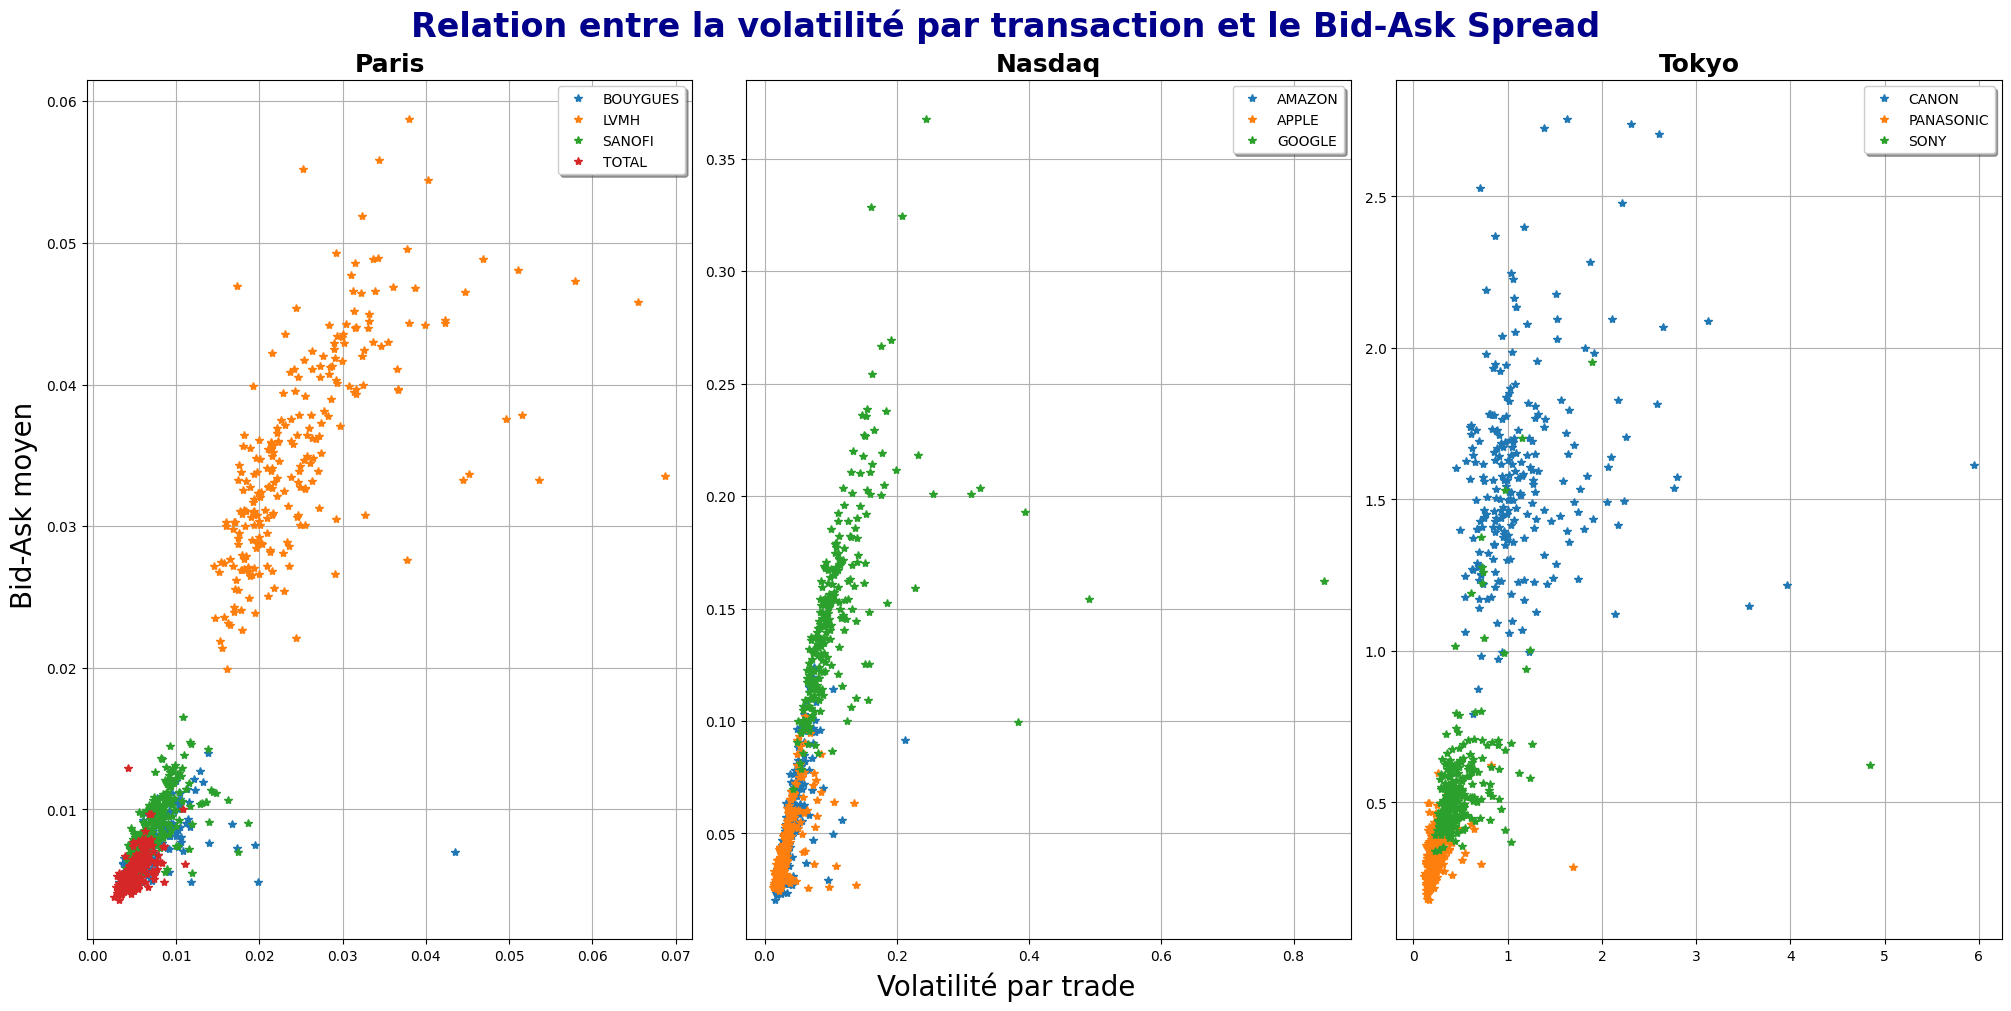

In [25]:
LR()

Here, the relationship seems to be followed perfectly, as the points are aligned much less dispersely than in the case of the normal spread. What's more, the slope is steeper than in the MRR model we saw in the first tutorial. Linear regression suggests an affine relationship between the two quantities.